# BREAST CANCER MODEL (RANDOM FOREST)


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score,  mean_squared_error
import seaborn as sns # for data visualization

from sklearn.model_selection import KFold, GridSearchCV
from scipy.optimize import minimize 
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

# Data loading 

In [29]:
cancer = load_breast_cancer()

# Convert the cancer dataset to a pandas dataframe
df_can = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Add the target variable to the dataframe
df_can['target'] = cancer.target

df_can

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [30]:
df_can.info() #We get information from the dataset features and their values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

## STANDARD SCALING (DATA PROCESSING) 

In [31]:
scaler = StandardScaler()

#Defyining the dataset variables

#target is the feature which indicates --> 0 means malignant tumor, 1 mean benign tumor

y = df_can['target'] 

x = df_can.drop(columns=['target']) #-drop = Remove rows or columns by specifying label names and corresponding axis, or by directly specifying index or column names. 
#This is so our "y" is the rest of our features in the dataset

# Split the data
x_train,x_test,y_train,y_test = train_test_split(x ,y , test_size =0.2, random_state =42)

#SCALING THE DATA

# Fit the scaler on the TRAINING data and transform it
X_train_scaled = scaler.fit_transform(x_train)

# Apply the same transformation to the TEST data
X_test_scaled = scaler.transform(x_test)

### note 

About fit_transform and transform

If you use .fit() or .fit_transform() on your Test Data, you are telling the scaler to calculate the average tumor radius of the new patients in the waiting room.

Why is this bad? Because in the real world, patients arrive one by one. You cannot tell a patient, "Please sit in the waiting room until 99 other people show up so I can calculate the new average radius before I diagnose you."

By looking at the whole test set to calculate an average, you are giving your model information about the "future" that it wouldn't have in a real-life scenario. This is called Data Leakage. It makes your model look like it's performing better than it actually will.

scaler.fit_transform(X_train): The scaler looks at the 400 past patients, calculates the average is 15mm (fit), and scales those past patients (transform).

scaler.transform(X_test): A new patient walks in. The scaler does not calculate a new average. It simply remembers the 15mm average from the past, compares the new patient to that historical 15mm, and scales their data accordingly.

# RandomForest

In [32]:
#Train the RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Train (fit) the model using the SCALED training data we talked about earlier
rf_model.fit(X_train_scaled, y_train)

# Evaluate its accuracy on the test set
# Ask the 100 doctors to vote on the new patients in the test set
rf_predictions = rf_model.predict(X_test_scaled)

# Compare their votes to the actual true diagnoses
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Accuracy: 96.49%


## RandomForest analysis

After training our model with the scaled training data and part of the real data (y_train). We then give new images of breasts to our model (X_test_scaled are new patients our model/doctor never has seen) and see how accurate the predictions of our model were according to our real remaining and untouched data (y_test). We observe after the test an accuracy of 96.49%, which is decent for our evaluation.

To understand how decision trees collectively improve robustness, we have to understand what RandomForest does. Robustness is a model's ability to maintain stable, accurate performance despite noisy, corrupted, or unexpected input data. How does our model achieve this? 

A random forest consists of common decision trees like Question 1: Is the tumor radius larger than 15mm? (If yes, go to Q2. If No, go to Q3). Question 2: Is the texture rough? (If Yes -> Malignant). The Problem is a single decision tree is like a doctor who memorizes the textbook perfectly but lacks common sense. If a new patient comes in who looks exactly like a past patient, the doctor is great. But if the patient is slightly different, the doctor gets confused and makes a bad guess. In machine learning, we call this overfitting (memorizing the training data too well) and having high variance (being too sensitive to small changes).

To add robustness to this decision tree we will have to add several things. The first one will be to add 100 trees/doctors instead of just one. We will have them all look at a new patient, and then you will take a majority vote. If 80 doctors say "Malignant" and 20 say "Benign," the final diagnosis is "Malignant." The only issue with this is that all doctors still have study the same dataset and will yield similar analysis of the patients. We need the doctors to be diverse, hence we want them to have slightly different experiences. This is where Bagging comes in. Instead of giving every doctor the exact same 400 files, you randomly draw 400 files from your cabinet for Doctor #1. But, you draw them with replacement. This means you might pull Patient A's file, copy it, put it back, and pull it again. This way a doctor may never see Patient B but see patient A twice.

Finally if we add randomness into the mixture we can make a highly robust model. We do this by when a doctor/tree is building their flowchart, they aren't allowed to look at all the symptoms. At every step, they are only given a random handful of features.

# Boosting: Gradient Boosting and AdaBoost

In this section we will be using new models to predict cancer on the data provided. They both work as an assembly line in which "doctors" make an analysis and they try to correct the mistakes of the doctor's analysis before them.

In [33]:
#Initialize both models
gb_model = GradientBoostingClassifier(random_state=42)
ada_model = AdaBoostClassifier(random_state=42)

# Train both models on the SCALED training data
gb_model.fit(X_train_scaled, y_train)
ada_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the test set
gb_predictions = gb_model.predict(X_test_scaled)
ada_predictions = ada_model.predict(X_test_scaled)

# 4. Calculate and print their accuracy
gb_accuracy = accuracy_score(y_test, gb_predictions)
ada_accuracy = accuracy_score(y_test, ada_predictions)

print(f"Gradient Boosting Accuracy: {gb_accuracy * 100:.2f}%")
print(f"AdaBoost Accuracy: {ada_accuracy * 100:.2f}%")

Gradient Boosting Accuracy: 95.61%
AdaBoost Accuracy: 96.49%


## Analysis

As we discussed earlier both of these models are based in an "assembly line" composed of *weak learning models*, this means that inside the assembly line we can imagine we have several different models/doctors which usually are very tiny, simple decision trees that only ask 1 or 2 questions. 

From the tests done we can see that Gradient Boosting Accuracy: 95.61% performed with 0,88 % less precision than the Random Forest, and that AdaBoost performed exactly the same (as RF). Let's now understand how both of this models work on the inside

AdaBoost (Adaptive Boosting) learns from mistakes by making the misclassified patients "heavier" (giving them a higher mathematical weight). This means that in the assembly line if the first doctor evaluates correctly 300 patients out of 400, the remaining misdiagnosed patients will be assigned a "mark or heavier weight" so that the next doctor in the line notices that it has to prioritize diagnosis on this 100 patients and if the second doctor misses only 2 out of a 100, those 2 will be passed into the next doctor with heavier weights and so on.

Gradient Boosting learns from mistakes by having the next model directly calculate and fix the mathematical difference (the "residual error") left by the previous model. Example Patient A is actually 55 years old, Intern 1 guesses: 50. (The error is +5). Intern 2 does NOT try to guess 55. Intern 2 looks at the patient and tries to guess +5! Intern 2 guesses "+3". Now the team's combined guess is 50 + 3 = 53. The remaining error is +2. Intern 3 steps up and tries to guess +2.

We can conclude that assigning to the misdiagnosed patients heavier weights so that the next weak learning models focus more on this patients is a more effective method that learning from errors of the previous models. Random Forest is great for making sure our model isn't wild and unstable (it reduces variance). Boosting is great at pushing for maximum accuracy. Because the model obsesses over the hardest-to-diagnose patients in our dataset.


# Voting classifier

So far, all ensembles (Random Forest, AdaBoost, Gradient Boosting) have been made entirely out of Decision Trees. In the medical world, this is like putting together a team made exclusively of cardiologists meaning they all share the exact same medical background.

A Voting Classifier takes a different approach. Instead of using 100 versions of the same algorithm, it creates a Medical Board made up of completely different algorithms.

"Used AI for this section"

In [36]:
#NORMAL MODEL TRAINING 

# (We increase max_iter for LogisticRegression just to ensure the math converges properly)
log_clf = LogisticRegression(random_state=42, max_iter=1000) #logistic Regression solves a complex math equation to find the answer. Sometimes it needs a lot of attempts (iterations) to finish the math. max_iter=1000

# Train them individually 
log_clf.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)

log_acc = accuracy_score(y_test, log_clf.predict(X_test_scaled))
rf_acc = accuracy_score(y_test, rf_model.predict(X_test_scaled))

# Check their individual accuracies of the models in the training fase before grouping them up.
print(f"Individual Logistic Regression Accuracy: {log_acc * 100:.2f}%")
print(f"Individual Random Forest Accuracy: {rf_acc * 100:.2f}%\n")

# MEDICAL BOARD // VOTING BEGINS
# Create the Voting Classifiers (we group both models to set them into the voting phase)
# We pass a list of tuples. ('name_we_give_it', the_model_variable)
estimators_list = [('lr', log_clf), ('rf', rf_model)]

# Hard Voting
voting_hard = VotingClassifier(estimators=estimators_list, voting='hard') #we load the models and tell them the rules of the voting (hard)
voting_hard.fit(X_train_scaled, y_train) #we train both models with hard voting for the training data and test data
hard_predictions = voting_hard.predict(X_test_scaled) #we test the models for X_test_scaled
hard_accuracy = accuracy_score(y_test, hard_predictions) #see how accurate they are

# Soft Voting
voting_soft = VotingClassifier(estimators=estimators_list, voting='soft')
voting_soft.fit(X_train_scaled, y_train)
soft_predictions = voting_soft.predict(X_test_scaled)
soft_accuracy = accuracy_score(y_test, soft_predictions)

# Evaluate and Compare
print(f"Hard Voting Accuracy: {hard_accuracy * 100:.2f}%")
print(f"Soft Voting Accuracy: {soft_accuracy * 100:.2f}%")

Individual Logistic Regression Accuracy: 97.37%
Individual Random Forest Accuracy: 96.49%

Hard Voting Accuracy: 96.49%
Soft Voting Accuracy: 97.37%


## Voting analysis 

To intemperate this results we must understand in what does Hard and Soft voting consist. The voting consists in when these completely different models/doctors look at a new patient, how do they agree on a final diagnosis?

- Hard Voting:

Hard voting is like democracy. Both models can either vote if the tumor is malign (0) or benign (1), at the end diagnosis is decided by majority.

- Soft Voting:

Soft voting is smarter, but it requires models that can calculate probabilities (how confident they are). Instead of just taking the final answer, the hospital director asks for their confidence levels:

Logistic Regression: "I am 51% sure it is Benign, and 49% sure it is Malignant."

Random Forest: "Are you crazy? I am 99% sure it is Malignant, and only 1% sure it is Benign!"

In Soft Voting, the director averages the probabilities:

Average Benign Probability: (51% + 1%) / 2 = 26%

Average Malignant Probability: (49% + 99%) / 2 = 74%

The final diagnosis is Malignant. Soft voting allows a highly confident model to overrule a model that is just barely guessing. Because of this, soft voting almost always performs better than hard voting.

### Result interpretation 

On their own, Logistic Regression (97.37%) performed slightly better than Random Forest (96.49%). This is because the breast cancer dataset is entirely made up of continuous numerical measurements (radius size, smoothness, area). Logistic Regression thrives on this kind of data because it draws a mathematical line right through the numbers.

Now let's observe the voting results. Hard Voting scored 96.49%, which is lower than our best individual model. It actually dragged our Logistic Regression score down. This is due to the fact that if both models agree we obtain a clear decision (100% malign or 100% benign). But what happens if Logistic Regression votes "Cancer" and Random Forest votes "Benign"? It is a 1-to-1 tie and when there is a tie, the algorithm flips a coin or uses a default rule to guess. Because of this, the slightly worse model (Random Forest) ended up pulling the better model (Logistic Regression) down to its level. There's    Machine Learning Rule of Thumb: If we are going to use Hard Voting, we should always use an odd number of models (like 3 or 5) so there is never a tie.

On the other hand Soft Voting scored 97.37%, perfectly matching our best individual model. The reason being Sof voting didn't just count the votes; it averaged the confidence. When the two models disagreed, the Logistic Regression model was likely saying. Because Soft Voting averages those percentages, the more confident (and in this case, more accurate) the model. It could be said that it prevented the Random Forest from ruining the Logistic Regression's correct answers.

While the Voting Classifier didn't beat our highest individual score (which happens sometimes when a single model is already extremely accurate), it proved that Soft Voting is much smarter and safer than Hard Voting.


# Model Comparison 

Used AI to make the graphs.

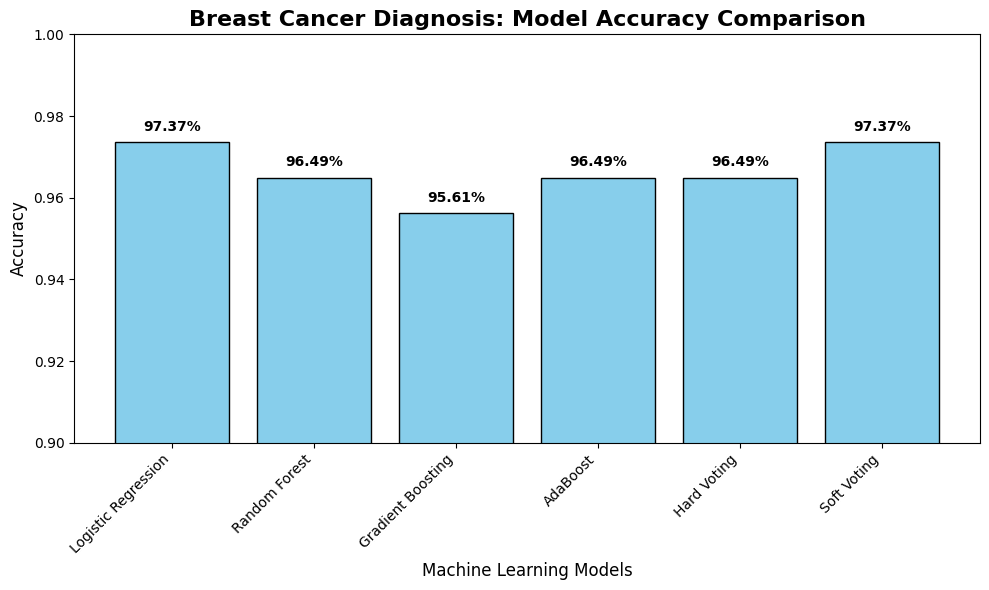

In [35]:
# Create lists for the chart
model_names = ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 
               'AdaBoost', 'Hard Voting', 'Soft Voting']


model_accuracies = [log_acc, rf_acc, gb_accuracy, ada_accuracy, hard_accuracy, soft_accuracy]


plt.figure(figsize=(10, 6))

bars = plt.bar(model_names, model_accuracies, color='skyblue', edgecolor='black')

plt.title('Breast Cancer Diagnosis: Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Machine Learning Models', fontsize=12)

# Rotate the names at the bottom so they don't overlap
plt.xticks(rotation=45, ha='right')

# Zoom in the Y-axis. Since all models are likely above 90%, starting at 0 makes 
# them all look identical. Let's start the graph at 0.90 (90%) to see the real differences!
plt.ylim(0.90, 1.0) 

# Add the exact percentages on top of each bar
for bar in bars:
    height = bar.get_height()
    # Puts the text right in the middle, slightly above the bar
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.002, 
             f'{height*100:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')


plt.tight_layout() # Keeps things from getting cut off
plt.show()

## Why do some models perform better than others?

The Breast Cancer dataset is heavily reliant on geometry (sizes, distances, and shapes of cells). Logistic Regression is accurate at drawing geometric lines to separate data, which is why it performs so well here. Tree-based models (like Random Forest) draw "boxes" rather than smooth lines, which sometimes isn't as perfect for geometric data. Soft voting obtained the same score as the logistic regression because when we assembled the estimators it trusted more at the end the Logistic Regression than the Random Forest.

In this case Random Forest, AdaBoost and Hard Voting performed exactly the same way and better than Gradient Boosting- This may be because GB is so aggressive at learning from mistakes that it can sometimes overfit—meaning it memorized the training data's quirks a little too well and got slightly confused by the brand new test patients. 

# Questions

- Which method performed best and why?
  
The best performing methods were Logistic Regressions and Soft Voting with an accuracy of 97.37 %. The reason they are the best was discussed in the markdown above, but basically is because for this type of dataset they adapt really well.

- How does bagging differ from boosting in your results?
  
  Random Forest performed identically to AdaBooster (96.49%) and better than Gradient Boosting (95.71 %) by 0.78%. The reasons were already discussed.

- When would you choose a VotingClassifier over individual models?

In my personal opinion for predictions/evaluations/diagnosis that need interpretations from different data or features I would always use VotingClassfier because it enables us to judge a result or diagnosis from different points of view making a more accurate and unbiased analysis.

- Can you think of ways to improve model performance even further? (e.g., hyperparameter tuning, feature selection, etc) "USED AI"

For Random Forest, we could test changing the n_estimators (hiring 500 doctors instead of 100) or adjusting the max_depth (limiting how many questions the doctors are allowed to ask to prevent them from over-complicating things). Tools like GridSearchCV in Python can automatically test hundreds of combinations to find the absolute best settings.

The breast cancer dataset has 30 different features, but not all of them are equally useful. Some features are highly correlated (for example, "mean radius" and "mean perimeter" basically measure the exact same thing). If we use techniques like a Correlation Matrix or PCA (Principal Component Analysis) to remove redundant or useless features, the models get less confused by "noise" and can focus only on the most critical symptoms.

We only split our data into a Training and Test set once (using test_size=0.2). It is possible we just got really "lucky" or "unlucky" with the specific 10% of patients that ended up in our test set. To truly prove our models are robust, we should use K-Fold Cross-Validation. This splits the dataset into multiple different chunks and tests the model 5 or 10 different times, averaging the final score to guarantee the model's true accuracy.